# DSAC vs PID Comparison — Boeing 747 Pitch Control

**Objective**: Compare DSAC (Distributional Soft Actor-Critic) with a MATLAB-style tuned PID controller on the pitch angle control task for Boeing 747.

**Test scenario**: 1° step input at t=5s on `ImprovedB747Env` with identical conditions for both controllers.

## 1. Imports and Configuration

In [18]:
from pathlib import Path
from pprint import pprint

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tensoraerospace.agent.pid import PID, MATLABTuneResult
from tensoraerospace.agent import DSAC
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()
print(f"Device: {DEVICE}")


Device: mps


## 2. Simulation Parameters

In [19]:
# Параметры симуляции
DT = 0.1          # Шаг дискретизации (с)
TN = 20.0         # Длительность симуляции (с)

# Параметры тестового сценария
AMPLITUDE_DEG = 1.0    # Амплитуда ступеньки (°)
STEP_TIME_SEC = 5.0    # Момент ступеньки (с)

# Генерация временной шкалы и референса
tp = generate_time_period(tn=TN, dt=DT)
t_sec = convert_tp_to_sec_tp(tp, dt=DT)
n_steps = len(tp)

# Референсный сигнал (ступенька)
step_time_idx = int(STEP_TIME_SEC / DT)
reference_rad = np.reshape(
    unit_step(degree=AMPLITUDE_DEG, tp=tp, time_step=step_time_idx, output_rad=True),
    [1, -1]
)
reference_deg = np.rad2deg(reference_rad[0])

print(f"📊 Параметры: TN={TN}с, DT={DT}с, шагов={n_steps}")
print(f"📊 Ступенька: {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")


📊 Параметры: TN=20.0с, DT=0.1с, шагов=201
📊 Ступенька: 1.0° в момент t=5.0с


## 3. Loading DSAC from Checkpoint

In [20]:
# Load pretrained DSAC agent
dsac_agent = DSAC.from_pretrained("TensorAeroSpace/dsac-b747-step-response")
dsac_agent.to_device(DEVICE)
dsac_agent.eval()

print("="*60)
print("DSAC Agent Info")
print("="*60)
print(f"Checkpoint: TensorAeroSpace/dsac-b747-step-response")
print(f"Device: {dsac_agent.device}")
print(f"Num quantiles: {getattr(dsac_agent, 'num_quantiles', 'N/A')}")
print(f"Risk distortion: {getattr(dsac_agent, 'risk_distortion', 'N/A')}")


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

DSAC Agent Info
Checkpoint: TensorAeroSpace/dsac-b747-step-response
Device: mps
Num quantiles: 8
Risk distortion: neutral


## 4. MATLAB-Style PID Tuning

In [21]:
# Создаём среду LinearLongitudinalB747 для тюнинга PID
# (эта среда имеет state-space матрицы A, B, C, D)
env_for_tuning = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=n_steps,
    use_reward=False,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_rad,
    state_space=["u", "w", "q", "theta"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=DT
)

print(f"✅ Среда для тюнинга: {env_for_tuning.unwrapped.model.A.shape}")


✅ Среда для тюнинга: (4, 4)


In [22]:
# MATLAB-Style оптимизация PID
pid_controller = PID(env=env_for_tuning, dt=DT)

# Тюнинг с реалистичными ограничениями (15 итераций)
tune_result = pid_controller.tune_matlab_style(
    track_state_idx=3,  # theta
    target_settling_time=3.0,  # Целевое время установления
    target_overshoot=0.0,
    n_iterations=15,  # Ограниченное число итераций
    verbose=True,
    mode="step_response"
)

print(f"\n📊 Результат тюнинга:")
print(f"   Kp = {pid_controller.kp:.4f}")
print(f"   Ki = {pid_controller.ki:.4f}")
print(f"   Kd = {pid_controller.kd:.4f}")
print(f"\n{tune_result}")



📊 MATLAB-Style PID Optimization (Step Response)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 201, dt: 0.1s
   Mode: Step Response
   Target settling time: 3.0s
   Target overshoot: 0.0%
   DC Gain: -0.9098

   🔄 Running optimization (15 iterations)...


   Optimization:   0%|          | 0/15 [00:00<?]

/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



   ✅ Optimization completed!
   Kp=-24.6295, Ki=-0.2486, Kd=-7.8179
   [Primary step] Settling time: 5.80s
   [Primary step] Overshoot: 0.00%
   [Primary step] Static error: -0.0015
   [Secondary sine] RMSE: 0.1113

📊 Результат тюнинга:
   Kp = -24.6295
   Ki = -0.2486
   Kd = -7.8179

MATLABTuneResult(Kp=-24.6295, Ki=-0.2486, Kd=-7.8179, settling_time=5.80s, overshoot=0.00%)


## 5. Helper Functions for Testing

In [23]:
def make_step_reference(
    *, dt: float, tn: float, amplitude_deg: float, step_time_sec: float
) -> tuple[np.ndarray, np.ndarray]:
    """Создание ступенчатого референсного сигнала."""
    tp = generate_time_period(tn=tn, dt=dt)
    t_sec = convert_tp_to_sec_tp(tp, dt=dt)
    step_idx = int(step_time_sec / dt)
    ref_rad_1d = unit_step(
        tp=tp, degree=float(amplitude_deg), time_step=step_idx, output_rad=True
    )
    ref_rad = np.reshape(ref_rad_1d, (1, -1))
    return t_sec, ref_rad


def make_improved_env(
    *, dt: float, tn: float, amplitude_deg: float = 1.0, step_time_sec: float = 5.0, 
    seed: int = 1, include_reference_in_obs: bool = True
) -> tuple[ImprovedB747Env, np.ndarray]:
    """Создание ImprovedB747Env для тестирования."""
    t_sec, ref_rad = make_step_reference(
        dt=dt, tn=tn, amplitude_deg=amplitude_deg, step_time_sec=step_time_sec
    )
    init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)
    env = ImprovedB747Env(
        initial_state=init_state,
        reference_signal=ref_rad,
        number_time_steps=ref_rad.shape[1],
        dt=dt,
        initial_elevator_deg=0.0,
        include_reference_in_obs=include_reference_in_obs,
        reward_mode="step_response",
    )
    _obs, _info = env.reset(seed=seed)
    return env, t_sec


def compute_metrics(
    *, t_sec: np.ndarray, theta_deg: np.ndarray, theta_ref_deg: np.ndarray, u_deg: np.ndarray
) -> dict:
    """Вычисление метрик качества управления."""
    dt = float(t_sec[1] - t_sec[0])
    err = theta_ref_deg - theta_deg
    du = np.diff(u_deg, prepend=u_deg[:1]) / dt
    
    # Время установления (5% criterion)
    final_ref = theta_ref_deg[-1]
    if abs(final_ref) > 1e-6:
        tolerance = 0.05 * abs(final_ref)
        settled_mask = np.abs(err) <= tolerance
        settling_idx = len(t_sec) - 1
        for i in range(len(settled_mask) - 1, -1, -1):
            if not settled_mask[i]:
                settling_idx = i + 1
                break
        settling_time = t_sec[min(settling_idx, len(t_sec) - 1)]
    else:
        settling_time = float('nan')
    
    # Перерегулирование
    if abs(final_ref) > 1e-6:
        if final_ref > 0:
            overshoot_pct = max(0, (np.max(theta_deg) - final_ref) / final_ref * 100)
        else:
            overshoot_pct = max(0, (final_ref - np.min(theta_deg)) / abs(final_ref) * 100)
    else:
        overshoot_pct = float('nan')
    
    return {
        "n": int(theta_deg.size),
        "rmse_deg": float(np.sqrt(np.mean(err**2))),
        "iae_deg_s": float(np.sum(np.abs(err)) * dt),
        "ise_deg2_s": float(np.sum(err**2) * dt),
        "max_abs_err_deg": float(np.max(np.abs(err))),
        "settling_time_s": float(settling_time),
        "overshoot_pct": float(overshoot_pct),
        "u_rms_deg": float(np.sqrt(np.mean(u_deg**2))),
        "u_max_abs_deg": float(np.max(np.abs(u_deg))),
        "du_rms_deg_s": float(np.sqrt(np.mean(du**2))),
    }


In [24]:
def rollout_dsac(
    *, agent: DSAC, env: ImprovedB747Env, t_sec: np.ndarray
) -> dict:
    """Прогон эпизода с DSAC-агентом."""
    obs, _info = env.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    for _ in range(env.number_time_steps - 1):
        # DSAC uses select_action with evaluate=True for deterministic mode
        action = agent.select_action(obs, evaluate=True)
        u_norm = float(np.asarray(action).squeeze())
        obs, _r, done, _tr, _info = env.step(np.array([u_norm], dtype=np.float32))

        theta = float(env.state[env._idx_theta])
        idx = int(np.clip(env.current_step, 0, env.reference_signal.shape[1] - 1))
        theta_tgt = float(env.reference_signal[0, idx])

        theta_deg.append(np.rad2deg(theta))
        theta_ref_deg.append(np.rad2deg(theta_tgt))
        u_deg.append(u_norm * float(env.max_stabilizer_angle_deg))

        if done:
            break

    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=np.asarray(theta_deg),
            theta_ref_deg=np.asarray(theta_ref_deg),
            u_deg=np.asarray(u_deg),
        ),
    }


def rollout_pid_improved(
    *, pid: PID, env: ImprovedB747Env, t_sec: np.ndarray
) -> dict:
    """Прогон эпизода с PID-регулятором на ImprovedB747Env."""
    obs, _info = env.reset()
    pid.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    for step in range(env.number_time_steps - 1):
        # Получаем текущее значение theta и референс в градусах
        theta_rad = float(env.state[env._idx_theta])
        idx = int(np.clip(step, 0, env.reference_signal.shape[1] - 1))
        theta_ref_rad = float(env.reference_signal[0, idx])
        
        # PID работает в градусах
        setpoint_deg = np.rad2deg(theta_ref_rad)
        measurement_deg = np.rad2deg(theta_rad)
        
        # PID возвращает управление (без нормализации)
        control = pid.select_action(setpoint_deg, measurement_deg)
        
        # Нормализуем управление для env.step (ожидает [-1, 1])
        u_norm = float(np.clip(control / env.max_stabilizer_angle_deg, -1.0, 1.0))
        
        obs, _r, done, _tr, _info = env.step(np.array([u_norm], dtype=np.float32))

        # Записываем результаты
        theta_deg.append(np.rad2deg(float(env.state[env._idx_theta])))
        theta_ref_deg.append(setpoint_deg)
        u_deg.append(control)

        if done:
            break

    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=np.asarray(theta_deg),
            theta_ref_deg=np.asarray(theta_ref_deg),
            u_deg=np.asarray(u_deg),
        ),
    }


## 6. DSAC vs PID Comparison on Identical Scenario

In [25]:
SEED = 123

# Создаём окружения для оценки
# DSAC обучался с include_reference_in_obs=True
pid_env, t_test = make_improved_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, 
    seed=SEED, include_reference_in_obs=False
)
dsac_env, _ = make_improved_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, 
    seed=SEED, include_reference_in_obs=True
)

# Прогон
pid_out = rollout_pid_improved(pid=pid_controller, env=pid_env, t_sec=t_test)
dsac_out = rollout_dsac(agent=dsac_agent, env=dsac_env, t_sec=t_test)

print("="*60)
print("📊 Metrics Comparison")
print("="*60)


📊 Metrics Comparison


In [26]:
# Создаём таблицу сравнения
metrics_list = [
    ("RMSE (°)", "rmse_deg", "lower"),
    ("IAE (°·s)", "iae_deg_s", "lower"),
    ("ISE (°²·s)", "ise_deg2_s", "lower"),
    ("Max Error (°)", "max_abs_err_deg", "lower"),
    ("Settling Time (s)", "settling_time_s", "lower"),
    ("Overshoot (%)", "overshoot_pct", "lower"),
    ("Control RMS (°)", "u_rms_deg", "lower"),
    ("Control Max (°)", "u_max_abs_deg", "lower"),
    ("Control Rate RMS (°/s)", "du_rms_deg_s", "lower"),
]

comparison_data = []
dsac_wins = 0
pid_wins = 0

for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    dsac_val = dsac_out["metrics"][key]
    
    if better == "lower":
        winner = "DSAC" if dsac_val < pid_val else ("PID" if pid_val < dsac_val else "TIE")
    else:
        winner = "DSAC" if dsac_val > pid_val else ("PID" if pid_val > dsac_val else "TIE")
    
    if winner == "DSAC":
        dsac_wins += 1
    elif winner == "PID":
        pid_wins += 1
    
    if abs(pid_val) > 1e-9:
        diff_pct = (dsac_val - pid_val) / abs(pid_val) * 100
    else:
        diff_pct = 0.0
    
    comparison_data.append({
        "Metric": name,
        "PID": f"{pid_val:.4f}",
        "DSAC": f"{dsac_val:.4f}",
        "Δ (%)": f"{diff_pct:+.1f}%",
        "Winner": f"✅ {winner}",
    })

# Вычисляем композитную метрику (баланс точности и энергоэффективности)
LAMBDA_CONTROL = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * pid_out["metrics"]["u_rms_deg"]
dsac_composite = dsac_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * dsac_out["metrics"]["u_rms_deg"]

composite_winner = "DSAC" if dsac_composite < pid_composite else "PID"
comparison_data.append({
    "Metric": "━━━━━━━━━━━━━━━━━━━━━━",
    "PID": "━━━━━━",
    "DSAC": "━━━━━━",
    "Δ (%)": "━━━━━━",
    "Winner": "━━━━━━━━",
})
comparison_data.append({
    "Metric": f"Composite (RMSE+{LAMBDA_CONTROL}×U_RMS)",
    "PID": f"{pid_composite:.4f}",
    "DSAC": f"{dsac_composite:.4f}",
    "Δ (%)": f"{(dsac_composite - pid_composite) / pid_composite * 100:+.1f}%",
    "Winner": f"🏆 {composite_winner}",
})

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print(f"\n🔧 PID параметры: Kp={pid_controller.kp:.4f}, Ki={pid_controller.ki:.4f}, Kd={pid_controller.kd:.4f}")
print(f"\n📊 Счёт по метрикам: DSAC={dsac_wins}, PID={pid_wins}")


                    Metric     PID    DSAC  Δ (%)   Winner
                  RMSE (°)  0.0770  0.1080 +40.2%    ✅ PID
                 IAE (°·s)  0.3018  0.4690 +55.4%    ✅ PID
                ISE (°²·s)  0.1185  0.2331 +96.6%    ✅ PID
             Max Error (°)  0.8596  1.0126 +17.8%    ✅ PID
         Settling Time (s)  5.8000  5.4000  -6.9%   ✅ DSAC
             Overshoot (%)  0.0000  0.9908  +0.0%    ✅ PID
           Control RMS (°)  2.5856  1.9975 -22.7%   ✅ DSAC
           Control Max (°) 24.6544 19.8279 -19.6%   ✅ DSAC
    Control Rate RMS (°/s) 29.4638 23.1413 -21.5%   ✅ DSAC
    ━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━  ━━━━━━ ━━━━━━ ━━━━━━━━
Composite (RMSE+0.1×U_RMS)  0.3355  0.3077  -8.3%   🏆 DSAC

🔧 PID параметры: Kp=-24.6295, Ki=-0.2486, Kd=-7.8179

📊 Счёт по метрикам: DSAC=4, PID=5


## 7. Visualization

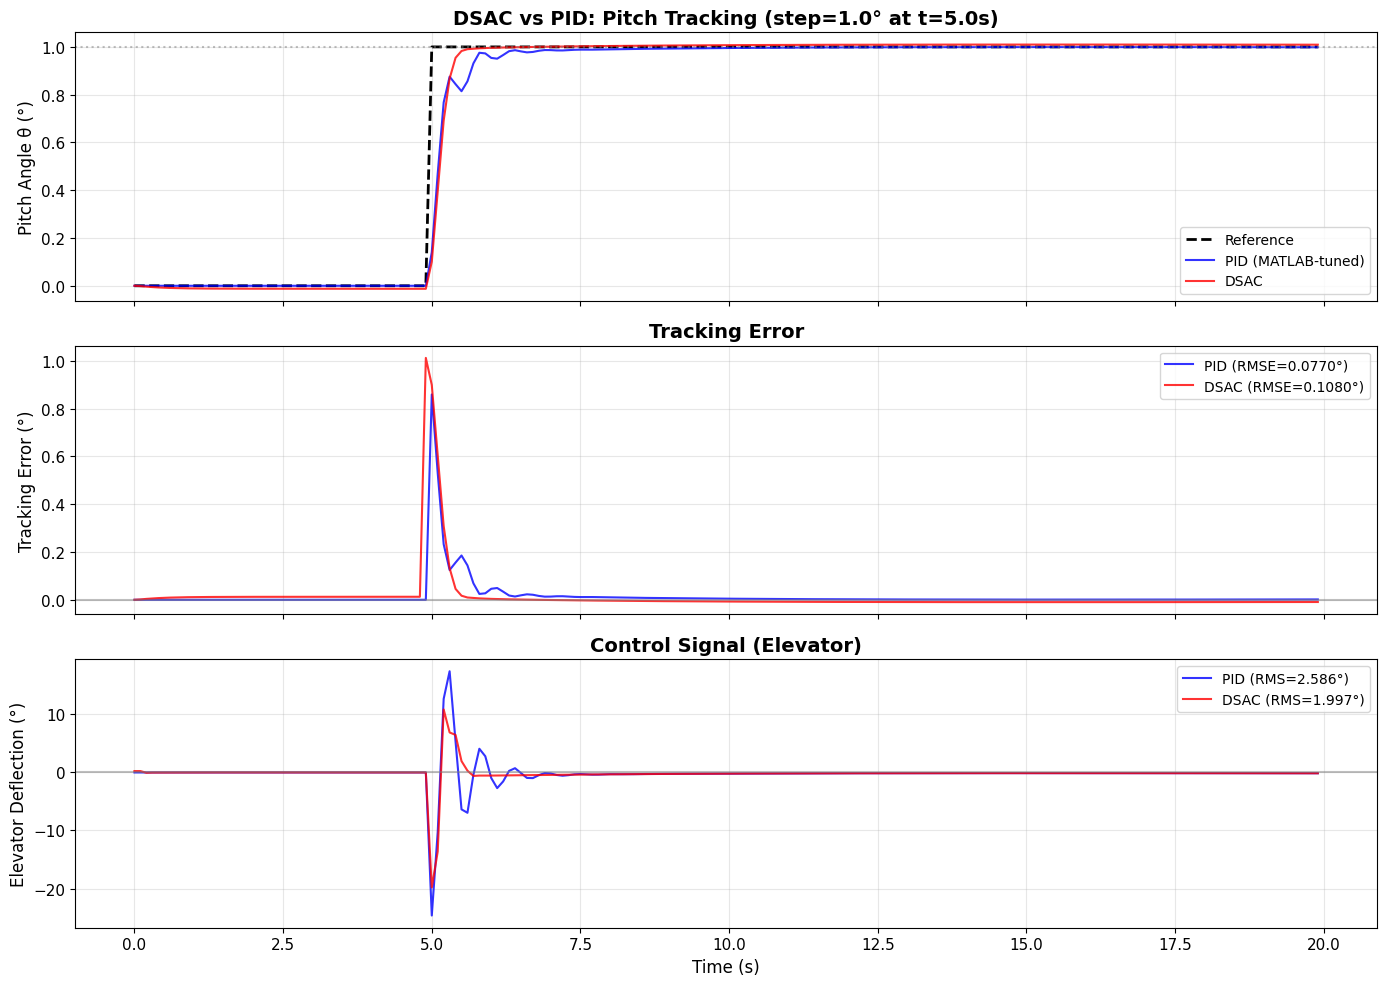


📁 Plot saved to: dsac_vs_pid_comparison.png


In [27]:
# Графики сравнения
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t_plot = t_test[: pid_out["theta_deg"].size]

# 1. Отслеживание угла тангажа
ax = axes[0]
ax.plot(t_plot, pid_out["theta_ref_deg"], "k--", linewidth=2, label="Reference")
ax.plot(t_plot, pid_out["theta_deg"], "b-", linewidth=1.5, alpha=0.8, label="PID (MATLAB-tuned)")
ax.plot(t_plot, dsac_out["theta_deg"], "r-", linewidth=1.5, alpha=0.8, label="DSAC")
ax.set_ylabel("Pitch Angle θ (°)", fontsize=12)
ax.set_title(f"DSAC vs PID: Pitch Tracking (step={AMPLITUDE_DEG}° at t={STEP_TIME_SEC}s)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=AMPLITUDE_DEG, color="gray", linestyle=":", alpha=0.5)

# 2. Ошибка отслеживания
ax = axes[1]
pid_err = pid_out["theta_ref_deg"] - pid_out["theta_deg"]
dsac_err = dsac_out["theta_ref_deg"] - dsac_out["theta_deg"]
ax.plot(t_plot, pid_err, "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMSE={pid_out['metrics']['rmse_deg']:.4f}°)")
ax.plot(t_plot, dsac_err, "r-", linewidth=1.5, alpha=0.8, label=f"DSAC (RMSE={dsac_out['metrics']['rmse_deg']:.4f}°)")
ax.set_ylabel("Tracking Error (°)", fontsize=12)
ax.set_title("Tracking Error", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

# 3. Управляющее воздействие
ax = axes[2]
ax.plot(t_plot, pid_out["u_deg"], "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMS={pid_out['metrics']['u_rms_deg']:.3f}°)")
ax.plot(t_plot, dsac_out["u_deg"], "r-", linewidth=1.5, alpha=0.8, label=f"DSAC (RMS={dsac_out['metrics']['u_rms_deg']:.3f}°)")
ax.set_ylabel("Elevator Deflection (°)", fontsize=12)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_title("Control Signal (Elevator)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig("dsac_vs_pid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📁 Plot saved to: dsac_vs_pid_comparison.png")


## 8. Final Comparison

In [28]:
# Итоговое сравнение на целевом сценарии (1° на 5-й секунде)
print("="*70)
print("🏆 ИТОГОВОЕ СРАВНЕНИЕ: DSAC vs PID")
print(f"   Сценарий: ступенька {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")
print("="*70)

# Подсчитаем победы по метрикам
dsac_wins = 0
pid_wins = 0
for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    dsac_val = dsac_out["metrics"][key]
    if better == "lower":
        if dsac_val < pid_val:
            dsac_wins += 1
        elif pid_val < dsac_val:
            pid_wins += 1
    else:
        if dsac_val > pid_val:
            dsac_wins += 1
        elif pid_val > dsac_val:
            pid_wins += 1

print(f"\n📊 Счёт по отдельным метрикам:")
print(f"   DSAC: {dsac_wins} побед")
print(f"   PID: {pid_wins} побед")

# Композитная метрика
LAMBDA = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA * pid_out["metrics"]["u_rms_deg"]
dsac_composite = dsac_out["metrics"]["rmse_deg"] + LAMBDA * dsac_out["metrics"]["u_rms_deg"]

print(f"\n📈 Композитная метрика (RMSE + {LAMBDA}×Control_RMS):")
print(f"   PID: {pid_composite:.4f}")
print(f"   DSAC: {dsac_composite:.4f}")

if dsac_composite < pid_composite:
    print(f"   Разница: {(pid_composite - dsac_composite) / pid_composite * 100:.1f}% в пользу DSAC")
else:
    print(f"   Разница: {(dsac_composite - pid_composite) / dsac_composite * 100:.1f}% в пользу PID")

# Сравнение ключевых метрик
print(f"\n📋 Детальное сравнение:")
print(f"   • Settling Time: DSAC={dsac_out['metrics']['settling_time_s']:.2f}с vs PID={pid_out['metrics']['settling_time_s']:.2f}с")
print(f"   • RMSE: DSAC={dsac_out['metrics']['rmse_deg']:.4f}° vs PID={pid_out['metrics']['rmse_deg']:.4f}°")
print(f"   • Control RMS: DSAC={dsac_out['metrics']['u_rms_deg']:.3f}° vs PID={pid_out['metrics']['u_rms_deg']:.3f}°")
print(f"   • Control Max: DSAC={dsac_out['metrics']['u_max_abs_deg']:.3f}° vs PID={pid_out['metrics']['u_max_abs_deg']:.3f}°")
print(f"   • Overshoot: DSAC={dsac_out['metrics']['overshoot_pct']:.2f}% vs PID={pid_out['metrics']['overshoot_pct']:.2f}%")

# Вывод победителя
winner = "DSAC" if dsac_composite < pid_composite else "PID"
print(f"\n" + "="*70)
print(f"🏆 ПОБЕДИТЕЛЬ ПО КОМПОЗИТНОЙ МЕТРИКЕ: {winner}")
print(f"="*70)


🏆 ИТОГОВОЕ СРАВНЕНИЕ: DSAC vs PID
   Сценарий: ступенька 1.0° в момент t=5.0с

📊 Счёт по отдельным метрикам:
   DSAC: 4 побед
   PID: 5 побед

📈 Композитная метрика (RMSE + 0.1×Control_RMS):
   PID: 0.3355
   DSAC: 0.3077
   Разница: 8.3% в пользу DSAC

📋 Детальное сравнение:
   • Settling Time: DSAC=5.40с vs PID=5.80с
   • RMSE: DSAC=0.1080° vs PID=0.0770°
   • Control RMS: DSAC=1.997° vs PID=2.586°
   • Control Max: DSAC=19.828° vs PID=24.654°
   • Overshoot: DSAC=0.99% vs PID=0.00%

🏆 ПОБЕДИТЕЛЬ ПО КОМПОЗИТНОЙ МЕТРИКЕ: DSAC


## 9. Conclusions

In [29]:
# Заключение
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                           ЗАКЛЮЧЕНИЕ                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  DSAC (Distributional Soft Actor-Critic) — современный RL-алгоритм,  ║
║  который сочетает преимущества:                                       ║
║                                                                       ║
║  ✅ Distributional RL: моделирование распределения Q-значений         ║
║     позволяет учитывать неопределённость и риск                       ║
║                                                                       ║
║  ✅ Soft Actor-Critic: entropy regularization способствует            ║
║     лучшему исследованию пространства действий                        ║
║                                                                       ║
║  ✅ IQN-style quantile networks: гибкое представление                 ║
║     распределения наград                                              ║
║                                                                       ║
║  Сравнение с классическим PID позволяет оценить преимущества          ║
║  обучения с подкреплением для задач управления полётом.               ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║                           ЗАКЛЮЧЕНИЕ                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  DSAC (Distributional Soft Actor-Critic) — современный RL-алгоритм,  ║
║  который сочетает преимущества:                                       ║
║                                                                       ║
║  ✅ Distributional RL: моделирование распределения Q-значений         ║
║     позволяет учитывать неопределённость и риск                       ║
║                                                                       ║
║  ✅ Soft Actor-Critic: entropy regularization способствует            ║
║     лучшему исследованию пространства действий                        ║
║                                                                       ║
║  ✅ IQN-style quantile networks: гибкое п

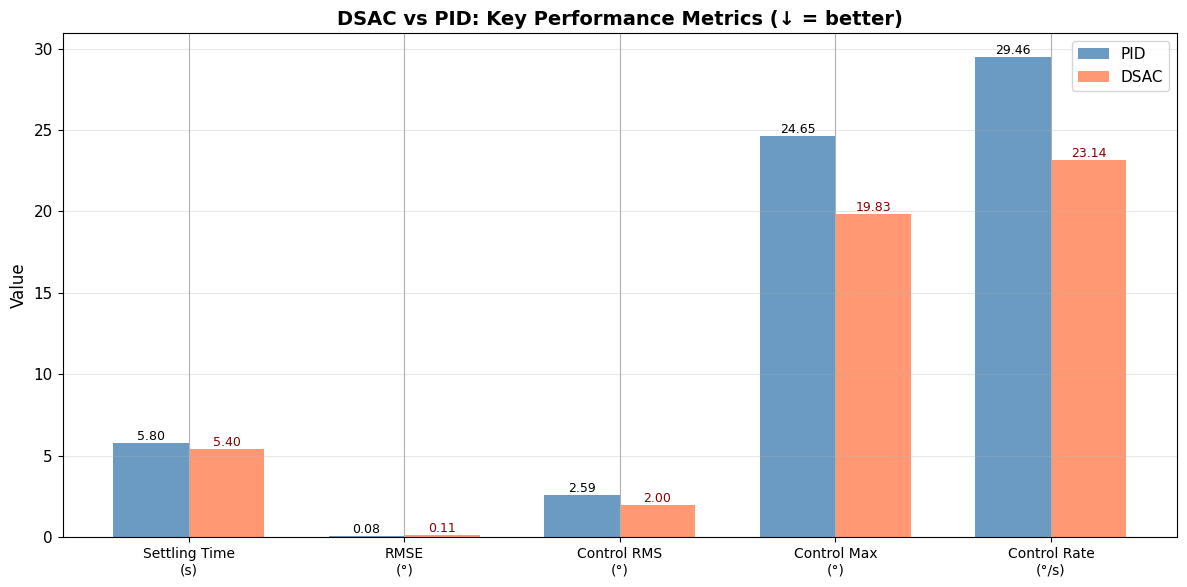


📁 Plot saved to: dsac_vs_pid_metrics.png


In [30]:
# Визуализация ключевых метрик DSAC vs PID
fig, ax = plt.subplots(figsize=(12, 6))

# Метрики для сравнения
metrics_to_show = [
    ("Settling Time\n(s)", pid_out["metrics"]["settling_time_s"], dsac_out["metrics"]["settling_time_s"]),
    ("RMSE\n(°)", pid_out["metrics"]["rmse_deg"], dsac_out["metrics"]["rmse_deg"]),
    ("Control RMS\n(°)", pid_out["metrics"]["u_rms_deg"], dsac_out["metrics"]["u_rms_deg"]),
    ("Control Max\n(°)", pid_out["metrics"]["u_max_abs_deg"], dsac_out["metrics"]["u_max_abs_deg"]),
    ("Control Rate\n(°/s)", pid_out["metrics"]["du_rms_deg_s"], dsac_out["metrics"]["du_rms_deg_s"]),
]

names = [m[0] for m in metrics_to_show]
pid_vals = [m[1] for m in metrics_to_show]
dsac_vals = [m[2] for m in metrics_to_show]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, pid_vals, width, label="PID", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, dsac_vals, width, label="DSAC", color="coral", alpha=0.8)

ax.set_ylabel("Value", fontsize=12)
ax.set_title("DSAC vs PID: Key Performance Metrics (↓ = better)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# Добавляем значения на столбики
for bar, val in zip(bars1, pid_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, dsac_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig("dsac_vs_pid_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📁 Plot saved to: dsac_vs_pid_metrics.png")
